# Master's Thesis: Multi-Agents in Fintech Regulatory Compliance
### **Student:** Ismail Dogan
### **Project:** Multi-Agent in Fintech Regulatory Compliance
### **Notebook:** 01 - CustomerRiskAgent Baseline Model

---

## 1. Objective

This notebook implements the **Customer Risk Agent** as part of the Multi-Agent System (MAS) for AML compliance.

**Goal:** Build a model that assesses **customer-level risk** by aggregating transaction patterns and behavioral features.

### Key Differences from Transaction Pattern Agent:
- **Unit of Analysis:** Customer (account holder) instead of individual transaction
- **Features:** Aggregated behavioral patterns, transaction history, risk indicators
- **Target:** Binary classification - High-Risk vs Low-Risk customer
- **Use Case:** KYC (Know Your Customer) risk assessment, customer due diligence (CDD)

> **Thesis Link:** Addresses **RQ1 (Architecture)** - specialized customer risk agent, and **RQ3 (Explainability)** - SHAP-based feature importance for regulatory reporting.

---

## 2. Methodology

### Data Source:
- Use the same **SAML-D transaction dataset**
- Aggregate transactions by `Sender_account` (customer ID)
- Create customer-level features from transaction history

### Timeframe:
- **Default:** 30 days of transaction history per customer
- **Configurable:** Can be adjusted for experimentation (7, 30, 60, 90 days)

### Customer Features:
1. **Transaction Volume Metrics:**
   - Total transaction count
   - Average/median/max transaction amount
   - Transaction velocity (transactions per day)

2. **Behavioral Patterns:**
   - Cross-border transaction ratio
   - High-risk currency usage
   - Cash transaction ratio
   - Time-based patterns (hour distribution)

3. **Risk Indicators:**
   - Fraud transaction ratio (from labels)
   - Structuring behavior (multiple small transactions)
   - Sudden volume spikes

4. **Network Features:**
   - Number of unique counterparties
   - Geographic diversity (countries transacted with)

### Target Variable:
- **High-Risk Customer:** If any fraudulent transactions in their history
- **Low-Risk Customer:** All transactions legitimate

### Model Training:
1. Train Logistic Regression, Random Forest, XGBoost
2. Handle class imbalance (SMOTE if needed)
3. Optimize for recall (catch high-risk customers)
4. Select champion model
5. Apply SHAP for explainability

---

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, auc, confusion_matrix, 
    recall_score, classification_report, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

/var/folders/qm/tx5zkys53fv3dxtmrrgrgmgc0000gn/T/ipykernel_51280/2288871896.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Configuration: Timeframe Setting

In [2]:
# ⚙️ CONFIGURABLE PARAMETERS
ANALYSIS_TIMEFRAME_DAYS = 30  # Can be changed: 7, 30, 60, 90
MIN_TRANSACTIONS_PER_CUSTOMER = 3  # Minimum transactions to consider customer
RANDOM_STATE = 42

print(f"📊 Customer Risk Analysis Configuration:")
print(f"   - Analysis Timeframe: {ANALYSIS_TIMEFRAME_DAYS} days")
print(f"   - Minimum Transactions: {MIN_TRANSACTIONS_PER_CUSTOMER}")
print(f"   - Random State: {RANDOM_STATE}")

📊 Customer Risk Analysis Configuration:
   - Analysis Timeframe: 30 days
   - Minimum Transactions: 3
   - Random State: 42


### Load Transaction Data

In [3]:
# Load the shared dataset from project root
df_transactions = pd.read_csv('../../../data/Anti Money Laundering Transaction Data (SAML-D).csv')

print(f"✅ Loaded {len(df_transactions):,} transactions")
print(f"📅 Date range: {df_transactions['Date'].min()} to {df_transactions['Date'].max()}")
print(f"👥 Unique customers (senders): {df_transactions['Sender_account'].nunique():,}")
print(f"🚨 Fraud transactions: {df_transactions['Is_laundering'].sum():,} ({df_transactions['Is_laundering'].mean():.2%})")

df_transactions.head()

✅ Loaded 9,504,852 transactions
📅 Date range: 2022-10-07 to 2023-08-23
👥 Unique customers (senders): 292,715
🚨 Fraud transactions: 9,873 (0.10%)
📅 Date range: 2022-10-07 to 2023-08-23
👥 Unique customers (senders): 292,715
🚨 Fraud transactions: 9,873 (0.10%)


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


### Data Preprocessing

In [4]:
# Convert date/time columns
df_transactions['Date'] = pd.to_datetime(df_transactions['Date'])
df_transactions['Time'] = pd.to_datetime(df_transactions['Time'], format='%H:%M:%S')
df_transactions['hour'] = df_transactions['Time'].dt.hour
df_transactions['day_of_week'] = df_transactions['Date'].dt.dayofweek

print("✅ Date/time features extracted")

✅ Date/time features extracted


## 📊 Customer Feature Engineering

Aggregate transaction-level data to customer-level features.

In [5]:
# Filter customers by timeframe (use most recent N days)
max_date = df_transactions['Date'].max()
cutoff_date = max_date - pd.Timedelta(days=ANALYSIS_TIMEFRAME_DAYS)

df_recent = df_transactions[df_transactions['Date'] >= cutoff_date].copy()

print(f"📅 Analysis period: {cutoff_date.date()} to {max_date.date()}")
print(f"📊 Transactions in timeframe: {len(df_recent):,}")
print(f"👥 Active customers in timeframe: {df_recent['Sender_account'].nunique():,}")

📅 Analysis period: 2023-07-24 to 2023-08-23
📊 Transactions in timeframe: 885,238
👥 Active customers in timeframe: 82,515


In [6]:
def create_customer_features(df, min_transactions=3):
    """
    Aggregate transaction data to create customer-level features
    
    Args:
        df: Transaction dataframe
        min_transactions: Minimum transactions required per customer
    
    Returns:
        Customer feature dataframe
    """
    customer_features = []
    
    for customer_id in df['Sender_account'].unique():
        customer_txns = df[df['Sender_account'] == customer_id]
        
        # Skip customers with too few transactions
        if len(customer_txns) < min_transactions:
            continue
        
        # === BASIC TRANSACTION METRICS ===
        features = {
            'customer_id': customer_id,
            'transaction_count': len(customer_txns),
            'total_amount': customer_txns['Amount'].sum(),
            'avg_amount': customer_txns['Amount'].mean(),
            'median_amount': customer_txns['Amount'].median(),
            'max_amount': customer_txns['Amount'].max(),
            'min_amount': customer_txns['Amount'].min(),
            'std_amount': customer_txns['Amount'].std(),
        }
        
        # === VELOCITY METRICS ===
        date_range = (customer_txns['Date'].max() - customer_txns['Date'].min()).days + 1
        features['active_days'] = date_range
        features['transactions_per_day'] = len(customer_txns) / max(date_range, 1)
        
        # === BEHAVIORAL PATTERNS ===
        features['cross_border_ratio'] = (customer_txns['Payment_type'] == 'Cross-border').mean()
        features['cash_transaction_ratio'] = (
            (customer_txns['Payment_type'] == 'Cash Deposit') | 
            (customer_txns['Payment_type'] == 'Cash Withdrawal')
        ).mean()
        
        # === RISK INDICATORS ===
        features['fraud_ratio'] = customer_txns['Is_laundering'].mean()
        features['has_fraud'] = int(customer_txns['Is_laundering'].sum() > 0)
        
        # Structuring indicator: multiple transactions of similar amounts
        amount_std = customer_txns['Amount'].std()
        amount_mean = customer_txns['Amount'].mean()
        features['amount_consistency'] = (amount_std / amount_mean) if amount_mean > 0 else 0
        
        # Large transactions (> 10000)
        features['large_transaction_ratio'] = (customer_txns['Amount'] > 10000).mean()
        
        # === NETWORK FEATURES ===
        features['unique_receivers'] = customer_txns['Receiver_account'].nunique()
        features['unique_receiver_countries'] = customer_txns['Receiver_bank_location'].nunique()
        features['receiver_diversity'] = features['unique_receivers'] / len(customer_txns)
        
        # === TIME PATTERNS ===
        features['night_transaction_ratio'] = ((customer_txns['hour'] >= 22) | (customer_txns['hour'] <= 6)).mean()
        features['weekend_transaction_ratio'] = (customer_txns['day_of_week'] >= 5).mean()
        
        # === CURRENCY DIVERSITY ===
        features['unique_currencies'] = customer_txns['Payment_currency'].nunique()
        
        # === PRIMARY LOCATION ===
        features['primary_location'] = customer_txns['Sender_bank_location'].mode()[0]
        
        customer_features.append(features)
    
    return pd.DataFrame(customer_features)

# Create customer features
print("🔄 Creating customer-level features...")
df_customers = create_customer_features(df_recent, min_transactions=MIN_TRANSACTIONS_PER_CUSTOMER)

print(f"\n✅ Customer feature engineering complete!")
print(f"👥 Total customers analyzed: {len(df_customers):,}")
print(f"🚨 High-risk customers: {df_customers['has_fraud'].sum():,} ({df_customers['has_fraud'].mean():.2%})")
print(f"📊 Features created: {len(df_customers.columns)}")

df_customers.head(10)

🔄 Creating customer-level features...

✅ Customer feature engineering complete!
👥 Total customers analyzed: 38,624
🚨 High-risk customers: 337 (0.87%)
📊 Features created: 23

✅ Customer feature engineering complete!
👥 Total customers analyzed: 38,624
🚨 High-risk customers: 337 (0.87%)
📊 Features created: 23


,customer_id,transaction_count,total_amount,avg_amount,median_amount,max_amount,min_amount,std_amount,active_days,transactions_per_day,...,has_fraud,amount_consistency,large_transaction_ratio,unique_receivers,unique_receiver_countries,receiver_diversity,night_transaction_ratio,weekend_transaction_ratio,unique_currencies,primary_location
0,5126550352,22,144934.51,6587.932273,6993.800,32447.06,58.29,6243.201412,30,0.733333,...,0,0.947672,0.045455,9,1,0.409091,0.318182,0.090909,1,UK
1,5565293861,267,2335041.39,8745.473371,8394.830,21554.75,70.32,3620.440476,30,8.900000,...,0,0.413979,0.367041,36,2,0.134831,0.176030,0.041199,2,UK
2,8295014793,50,156001.51,3120.030200,2680.835,10480.92,517.00,2349.358900,30,1.666667,...,0,0.752992,0.020000,10,1,0.200000,0.260000,0.300000,1,UK
3,2530062431,19,83654.91,4402.890000,4867.120,9371.50,23.60,2808.666941,31,0.612903,...,0,0.637914,0.000000,14,1,0.736842,0.368421,0.263158,1,UK
4,9545425933,44,159185.95,3617.862500,3607.520,20887.39,103.05,4077.475508,30,1.466667,...,0,1.127040,0.068182,13,1,0.295455,0.250000,0.431818,2,UK
5,699474596,120,1043781.27,8698.177250,7313.050,18641.09,34.17,4784.896973,26,4.615385,...,0,0.550103,0.433333,10,2,0.083333,0.158333,0.000000,1,UK
6,2118817860,28,180349.43,6441.051071,5615.120,47631.96,45.79,10000.360339,29,0.965517,...,0,1.552598,0.107143,9,1,0.321429,0.178571,0.250000,1,UK
7,7939476806,42,446223.70,10624.373810,1642.385,222574.71,37.10,36075.039815,30,1.400000,...,0,3.395498,0.119048,21,1,0.500000,0.190476,0.166667,1,UK
8,7043852284,12,81152.19,6762.682500,6763.395,6809.87,6712.05,31.764032,1,12.000000,...,0,0.004697,0.000000,1,1,0.083333,0.333333,0.000000,1,UK
9,5628974687,23,121614.30,5287.578261,2453.450,28219.24,88.95,6599.291507,29,0.793103,...,0,1.248074,0.173913,15,2,0.652174,0.347826,0.260870,1,UK


### Feature Statistics

In [7]:
# Display feature statistics
df_customers.describe()

,customer_id,transaction_count,total_amount,avg_amount,median_amount,max_amount,min_amount,std_amount,active_days,transactions_per_day,...,fraud_ratio,has_fraud,amount_consistency,large_transaction_ratio,unique_receivers,unique_receiver_countries,receiver_diversity,night_transaction_ratio,weekend_transaction_ratio,unique_currencies
count,3.862400e+04,38624.000000,3.862400e+04,3.862400e+04,38624.000000,3.862400e+04,38624.000000,3.862400e+04,38624.000000,38624.000000,...,38624.000000,38624.000000,38624.000000,38624.000000,38624.000000,38624.000000,38624.000000,38624.000000,38624.000000,38624.000000
mean,5.008806e+09,21.611019,1.801455e+05,8.297993e+03,6361.986356,3.178032e+04,4875.699614,6.382619e+03,15.639162,5.940225,...,0.002278,0.008725,0.709019,0.259402,6.600663,1.304707,0.309279,0.197393,0.250825,1.211449
std,2.897219e+09,34.493618,3.544690e+05,1.004766e+04,6169.416916,8.546685e+04,6352.824295,2.196036e+04,13.031546,10.592639,...,0.038717,0.093001,0.875863,0.367271,7.495972,0.674257,0.242755,0.123763,0.311601,0.550250
min,9.217200e+04,3.000000,2.045700e+02,6.819000e+01,36.770000,8.863000e+01,5.080000,2.895589e+00,1.000000,0.096774,...,0.000000,0.000000,0.000267,0.000000,1.000000,1.000000,0.076923,0.000000,0.000000,1.000000
25%,2.497061e+09,12.000000,5.870496e+04,4.039900e+03,2009.927500,6.819573e+03,123.895000,6.350032e+01,1.000000,0.586207,...,0.000000,0.000000,0.006500,0.000000,1.000000,1.000000,0.083333,0.111111,0.000000,1.000000
50%,5.011377e+09,12.000000,9.915842e+04,6.431417e+03,4858.052500,1.225940e+04,1377.415000,1.077764e+03,21.000000,1.233333,...,0.000000,0.000000,0.293142,0.088235,1.000000,1.000000,0.200000,0.186555,0.181818,1.000000
75%,7.521390e+09,22.000000,1.640277e+05,1.013013e+04,8735.268750,2.275040e+04,8019.015000,5.499612e+03,29.000000,12.000000,...,0.000000,0.000000,1.202658,0.307907,12.000000,1.000000,0.541667,0.250000,0.333333,1.000000
max,9.999767e+09,309.000000,3.727450e+06,1.090498e+06,306449.980000,3.194040e+06,73192.910000,1.822129e+06,31.000000,260.000000,...,1.000000,1.000000,5.870927,1.000000,45.000000,7.000000,1.000000,1.000000,1.000000,9.000000


### Class Distribution Analysis

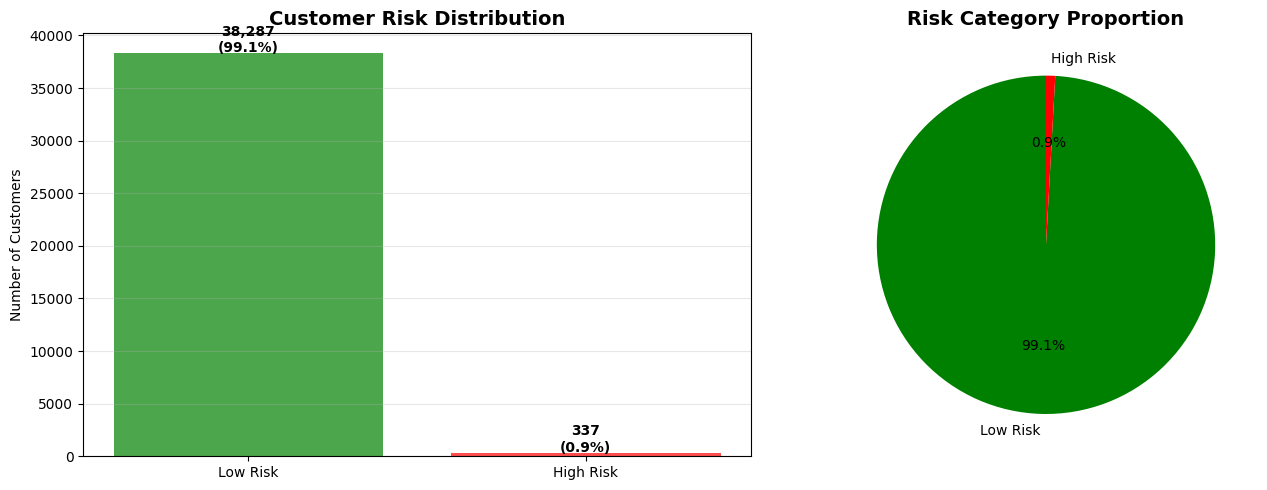


⚖️ Class Imbalance Ratio: 1:113.6


In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
class_counts = df_customers['has_fraud'].value_counts()
axes[0].bar(['Low Risk', 'High Risk'], class_counts.values, color=['green', 'red'], alpha=0.7)
axes[0].set_title('Customer Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_customers):.1%})', 
                ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Low Risk', 'High Risk'], 
           autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
axes[1].set_title('Risk Category Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚖️ Class Imbalance Ratio: 1:{class_counts.values[0]/class_counts.values[1]:.1f}")

---
## 🎯 Model Training

Now we'll train three models to assess customer risk and compare their performance.

### Step 1: Prepare Features for Modeling

In [9]:
# Separate features and target
# Exclude non-numeric columns: customer_id, primary_location, fraud_ratio (leakage)
X = df_customers.drop(['customer_id', 'primary_location', 'has_fraud', 'fraud_ratio'], axis=1)
y = df_customers['has_fraud']

print(f"✅ Feature matrix shape: {X.shape}")
print(f"✅ Target distribution:\n{y.value_counts()}")
print(f"\n📋 Features used for modeling ({len(X.columns)}):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Feature matrix shape: (38624, 19)
✅ Target distribution:
has_fraud
0    38287
1      337
Name: count, dtype: int64

📋 Features used for modeling (19):
    1. transaction_count
    2. total_amount
    3. avg_amount
    4. median_amount
    5. max_amount
    6. min_amount
    7. std_amount
    8. active_days
    9. transactions_per_day
   10. cross_border_ratio
   11. cash_transaction_ratio
   12. amount_consistency
   13. large_transaction_ratio
   14. unique_receivers
   15. unique_receiver_countries
   16. receiver_diversity
   17. night_transaction_ratio
   18. weekend_transaction_ratio
   19. unique_currencies


### Step 2: Train/Test Split

In [10]:
# Split data: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"✅ Training set: {len(X_train):,} customers")
print(f"   - Low Risk: {(y_train == 0).sum():,}")
print(f"   - High Risk: {(y_train == 1).sum():,}")
print(f"\n✅ Test set: {len(X_test):,} customers")
print(f"   - Low Risk: {(y_test == 0).sum():,}")
print(f"   - High Risk: {(y_test == 1).sum():,}")

✅ Training set: 27,036 customers
   - Low Risk: 26,800
   - High Risk: 236

✅ Test set: 11,588 customers
   - Low Risk: 11,487
   - High Risk: 101


### Step 3: Feature Scaling

In [11]:
# Standardize features (important for Logistic Regression and SMOTE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features standardized (mean=0, std=1)")
print(f"   Training set shape: {X_train_scaled.shape}")
print(f"   Test set shape: {X_test_scaled.shape}")

✅ Features standardized (mean=0, std=1)
   Training set shape: (27036, 19)
   Test set shape: (11588, 19)


### Step 4: Handle Class Imbalance with SMOTE

**Why SMOTE?** Our dataset has a severe imbalance (1:113.6). SMOTE will oversample the minority class (high-risk customers) to create a balanced training set.

In [12]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("✅ SMOTE applied to training set")
print(f"\n📊 Before SMOTE:")
print(f"   - Low Risk: {(y_train == 0).sum():,}")
print(f"   - High Risk: {(y_train == 1).sum():,}")
print(f"   - Ratio: 1:{(y_train == 0).sum() / (y_train == 1).sum():.1f}")

print(f"\n📊 After SMOTE:")
print(f"   - Low Risk: {(y_train_resampled == 0).sum():,}")
print(f"   - High Risk: {(y_train_resampled == 1).sum():,}")
print(f"   - Ratio: 1:{(y_train_resampled == 0).sum() / (y_train_resampled == 1).sum():.1f}")

print(f"\n⚠️ Note: Test set remains unchanged (no data leakage)")

✅ SMOTE applied to training set

📊 Before SMOTE:
   - Low Risk: 26,800
   - High Risk: 236
   - Ratio: 1:113.6

📊 After SMOTE:
   - Low Risk: 26,800
   - High Risk: 26,800
   - Ratio: 1:1.0

⚠️ Note: Test set remains unchanged (no data leakage)


### Step 5: Train Models

We'll train three models and compare their performance:
1. **Logistic Regression** - Interpretable baseline
2. **Random Forest** - Ensemble method with feature importance
3. **XGBoost** - Gradient boosting (likely champion for SHAP)

In [13]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', base_score=0.5)
}

# Train all models
trained_models = {}
print("🚀 Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    print(f"✅ {name} trained successfully\n")

print("✅ All models trained!")

🚀 Training models...

Training Logistic Regression...
✅ Logistic Regression trained successfully

Training Random Forest...
✅ Logistic Regression trained successfully

Training Random Forest...
✅ Random Forest trained successfully

Training XGBoost...
✅ XGBoost trained successfully

✅ All models trained!
✅ Random Forest trained successfully

Training XGBoost...
✅ XGBoost trained successfully

✅ All models trained!


---
## 📊 Model Evaluation

Evaluate all models on the test set and compare performance.

### Generate Predictions

In [14]:
# Generate predictions for all models
predictions = {}
probabilities = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]  # Probability of high-risk

print("✅ Predictions generated for all models")

✅ Predictions generated for all models


### Performance Metrics Comparison

In [15]:
# Calculate metrics for each model
from sklearn.metrics import precision_score, f1_score

results = []

for name in trained_models.keys():
    y_pred = predictions[name]
    y_prob = probabilities[name]
    
    # Calculate metrics
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# Create comparison dataframe
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('ROC-AUC', ascending=False)

print("📊 Model Performance Comparison (Test Set):\n")
print(df_results.to_string(index=False))

# Highlight champion model
champion_model_name = df_results.iloc[0]['Model']
print(f"\n🏆 Champion Model: {champion_model_name}")
print(f"   Best ROC-AUC: {df_results.iloc[0]['ROC-AUC']:.4f}")

📊 Model Performance Comparison (Test Set):

              Model   Recall  Precision  F1-Score  ROC-AUC
            XGBoost 0.267327   0.490909  0.346154 0.905119
      Random Forest 0.247525   0.454545  0.320513 0.898844
Logistic Regression 0.732673   0.019655  0.038282 0.814729

🏆 Champion Model: XGBoost
   Best ROC-AUC: 0.9051


### Confusion Matrices

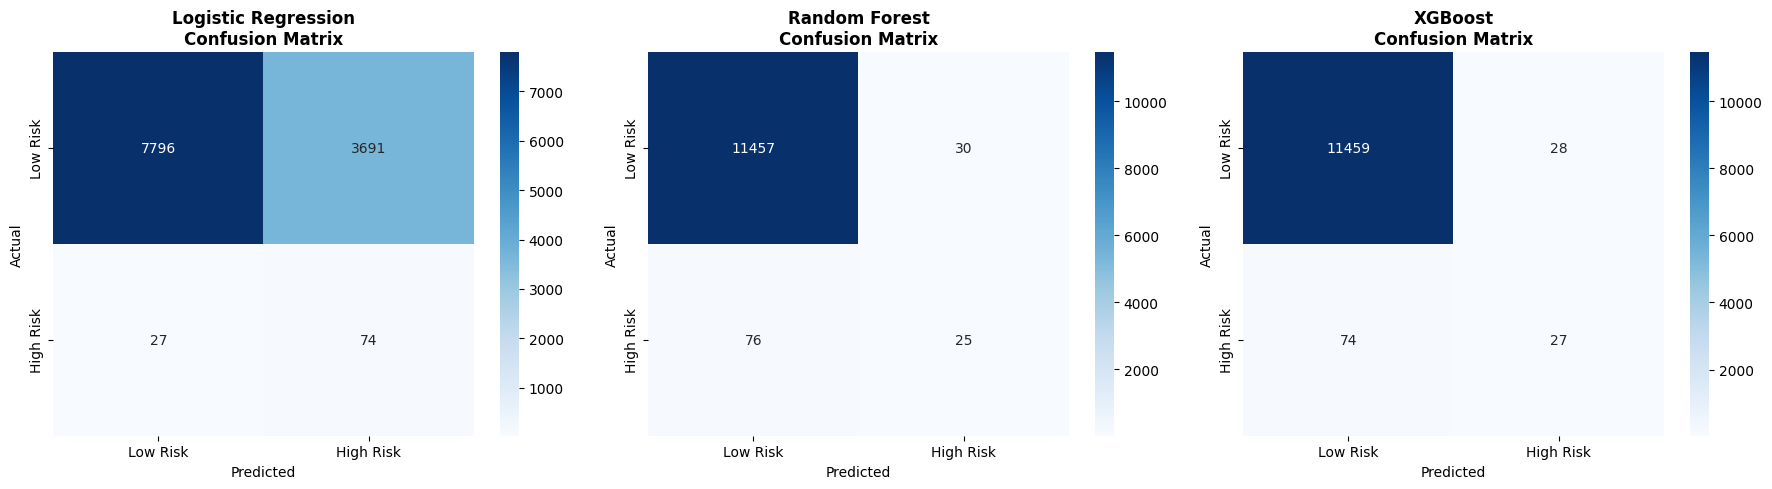

In [16]:
# Visualize confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### Detailed Classification Reports

In [17]:
# Print detailed classification report for champion model
print(f"📋 Detailed Classification Report: {champion_model_name}\n")
print("="*60)
print(classification_report(y_test, predictions[champion_model_name], 
                           target_names=['Low Risk', 'High Risk']))
print("="*60)

📋 Detailed Classification Report: XGBoost

              precision    recall  f1-score   support

    Low Risk       0.99      1.00      1.00     11487
   High Risk       0.49      0.27      0.35       101

    accuracy                           0.99     11588
   macro avg       0.74      0.63      0.67     11588
weighted avg       0.99      0.99      0.99     11588



---
## 🔍 Explainable AI (SHAP Analysis)

Apply SHAP to understand which features drive customer risk predictions.

### Install and Import SHAP

In [18]:
# Install SHAP if not already installed
try:
    import shap
    print("✅ SHAP already installed")
except ImportError:
    print("📦 Installing SHAP...")
    import sys
    !{sys.executable} -m pip install shap -q
    import shap
    print("✅ SHAP installed successfully")

✅ SHAP already installed


### Generate SHAP Values for Champion Model

In [20]:
# Get champion model
champion_model = trained_models[champion_model_name]

# Create SHAP explainer with robust error handling
print(f"🔄 Creating SHAP explainer for {champion_model_name}...")

if champion_model_name == 'XGBoost':
    # Try multiple approaches to avoid base_score parsing issues
    try:
        # Attempt 1: Use model_output='raw' to bypass base_score parsing
        explainer = shap.TreeExplainer(champion_model, model_output='raw')
        print("✅ SHAP explainer created (using model_output='raw')")
    except Exception as e:
        print(f"⚠️ First attempt failed: {str(e)[:100]}")
        try:
            # Attempt 2: Use default behavior
            explainer = shap.TreeExplainer(champion_model)
            print("✅ SHAP explainer created (using default)")
        except Exception as e2:
            print(f"❌ Second attempt failed: {str(e2)[:100]}")
            # Attempt 3: Use KernelExplainer as fallback (slower but works)
            print("🔄 Falling back to KernelExplainer (slower but compatible)...")
            background = shap.sample(X_train_resampled, 100)
            explainer = shap.KernelExplainer(champion_model.predict_proba, background)
            print("✅ SHAP KernelExplainer created")
            
elif champion_model_name == 'Random Forest':
    try:
        explainer = shap.TreeExplainer(champion_model, model_output='raw')
        print("✅ SHAP explainer created (using model_output='raw')")
    except:
        explainer = shap.TreeExplainer(champion_model)
        print("✅ SHAP explainer created")
else:  # Logistic Regression
    explainer = shap.LinearExplainer(champion_model, X_train_resampled)
    print("✅ SHAP LinearExplainer created")

# Calculate SHAP values on test set (use sample for speed)
sample_size = min(500, len(X_test_scaled))
X_test_sample = X_test_scaled[:sample_size]

print(f"🔄 Calculating SHAP values for {sample_size} test samples...")
shap_values = explainer.shap_values(X_test_sample)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    # For binary classification, SHAP may return a list [class0_values, class1_values]
    shap_values = shap_values[1]  # Use positive class (high-risk)
    print("✅ SHAP values computed (using high-risk class)")
else:
    print("✅ SHAP values computed!")

🔄 Creating SHAP explainer for XGBoost...
⚠️ First attempt failed: could not convert string to float: '[5E-1]'
❌ Second attempt failed: could not convert string to float: '[5E-1]'
🔄 Falling back to KernelExplainer (slower but compatible)...
✅ SHAP KernelExplainer created
🔄 Calculating SHAP values for 500 test samples...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ SHAP values computed!


### SHAP Summary Plot - Feature Importance

<Figure size 1000x800 with 0 Axes>

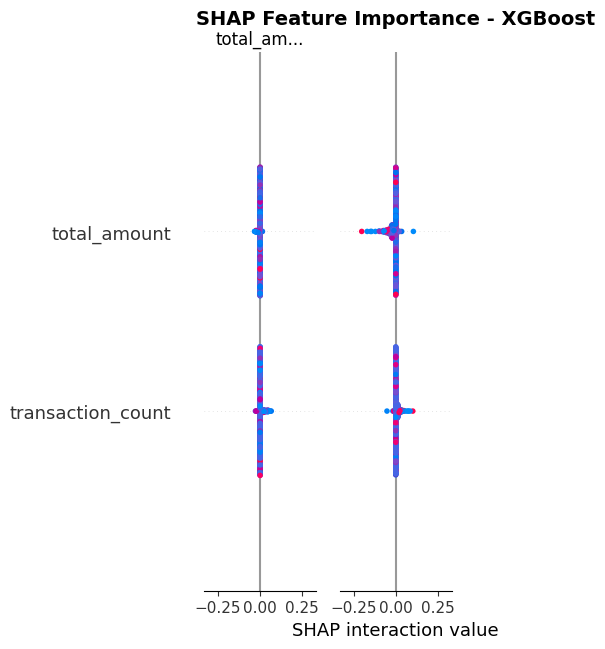


📊 Interpretation:
   - Features are ranked by importance (top = most important)
   - Red = high feature value, Blue = low feature value
   - Right = increases risk prediction, Left = decreases risk prediction


In [21]:
# SHAP Summary Plot - shows which features are most important
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns, show=False)
plt.title(f'SHAP Feature Importance - {champion_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   - Features are ranked by importance (top = most important)")
print("   - Red = high feature value, Blue = low feature value")
print("   - Right = increases risk prediction, Left = decreases risk prediction")

### SHAP Bar Plot - Mean Absolute Impact

<Figure size 1000x800 with 0 Axes>

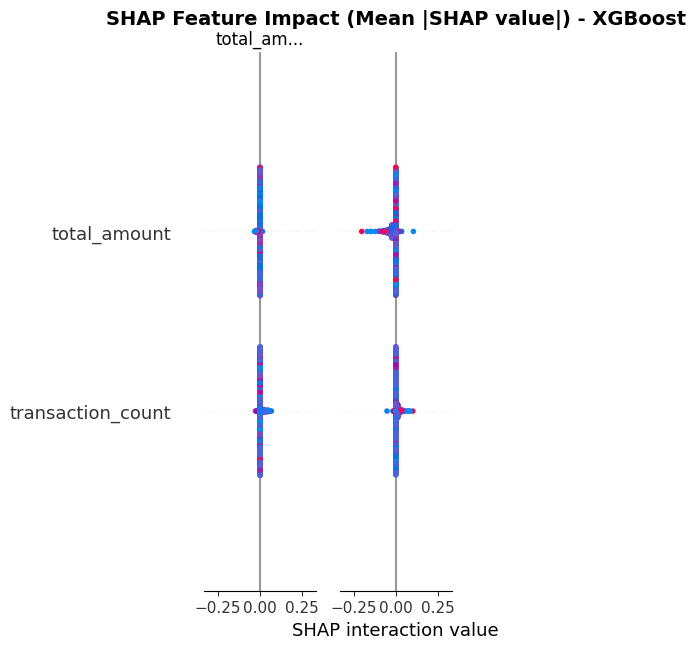


📊 Top 5 Most Important Features:
   8. active_days: 0.1181
   11. cash_transaction_ratio: 0.1079
   14. unique_receivers: 0.0956
   16. receiver_diversity: 0.0300
   18. weekend_transaction_ratio: 0.0273


In [22]:
# SHAP Bar Plot - average magnitude of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=X.columns, plot_type='bar', show=False)
plt.title(f'SHAP Feature Impact (Mean |SHAP value|) - {champion_model_name}', 
         fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n📊 Top 5 Most Important Features:")

# Handle SHAP values shape - ensure it's 2D
if len(shap_values.shape) > 2:
    # If 3D, take the last dimension (high-risk class)
    shap_values_2d = shap_values[:, :, -1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
else:
    shap_values_2d = shap_values

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(shap_values_2d).mean(axis=0)
}).sort_values('importance', ascending=False)

for idx, row in feature_importance.head(5).iterrows():
    print(f"   {idx+1}. {row['feature']}: {row['importance']:.4f}")

### SHAP Force Plot - Individual Prediction Example

In [27]:
# Initialize JS visualization
shap.initjs()

# Show force plot for a high-risk customer (if any in sample)
high_risk_indices = [i for i in range(len(y_test[:sample_size])) if y_test.iloc[i] == 1]

if len(high_risk_indices) > 0:
    idx = high_risk_indices[0]
    print(f"🔍 Force plot for high-risk customer (index {idx}):")
    print(f"   Actual Label: High Risk")
    print(f"   Predicted Probability: {probabilities[champion_model_name][idx]:.2%}\n")
    
    # Handle different expected_value formats (scalar vs array)
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        # For binary classification with list/array expected_value
        expected_val = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        # Scalar expected_value
        expected_val = explainer.expected_value
    
    # Extract SHAP values for this customer (handle 2D case)
    customer_shap_values = shap_values[idx]
    if len(customer_shap_values.shape) > 1:
        # If 2D (from KernelExplainer with binary classification), take high-risk class
        customer_shap_values = customer_shap_values[:, 1] if customer_shap_values.shape[1] > 1 else customer_shap_values[:, 0]
    
    try:
        # Try force plot without matplotlib first (interactive version)
        shap.force_plot(expected_val, customer_shap_values, X_test_sample[idx], 
                       feature_names=X.columns, matplotlib=False)
        
        print("\n📊 Interpretation:")
        print("   - Base value: Average model prediction")
        print("   - Red features: Push prediction towards HIGH RISK")
        print("   - Blue features: Push prediction towards LOW RISK")
    except Exception as e:
        print(f"⚠️ Could not generate interactive force plot: {str(e)[:100]}")
        print("\n📊 Feature Contributions for this customer:")
        # Show top contributing features as alternative
        feature_contribs = pd.DataFrame({
            'feature': X.columns,
            'shap_value': customer_shap_values
        }).sort_values('shap_value', key=abs, ascending=False)
        
        print(f"\n🔴 Top 5 Features Increasing Risk:")
        for _, row in feature_contribs[feature_contribs['shap_value'] > 0].head(5).iterrows():
            print(f"   {row['feature']}: +{row['shap_value']:.4f}")
        
        print(f"\n🔵 Top 5 Features Decreasing Risk:")
        for _, row in feature_contribs[feature_contribs['shap_value'] < 0].head(5).iterrows():
            print(f"   {row['feature']}: {row['shap_value']:.4f}")
else:
    print("⚠️ No high-risk customers in sample")

🔍 Force plot for high-risk customer (index 8):
   Actual Label: High Risk
   Predicted Probability: 0.03%


📊 Interpretation:
   - Base value: Average model prediction
   - Red features: Push prediction towards HIGH RISK
   - Blue features: Push prediction towards LOW RISK


---
## 💾 Save Champion Model

Save the trained model, scaler, and metadata for production deployment.

In [29]:
import pickle
from datetime import datetime
import os

# Create trained_models directory if it doesn't exist
model_dir = '../trained_models'
os.makedirs(model_dir, exist_ok=True)

# Prepare model artifacts
model_artifacts = {
    'model': champion_model,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'model_name': champion_model_name,
    'metrics': {
        'recall': df_results.iloc[0]['Recall'],
        'precision': df_results.iloc[0]['Precision'],
        'f1_score': df_results.iloc[0]['F1-Score'],
        'roc_auc': df_results.iloc[0]['ROC-AUC']
    },
    'training_config': {
        'timeframe_days': ANALYSIS_TIMEFRAME_DAYS,
        'min_transactions': MIN_TRANSACTIONS_PER_CUSTOMER,
        'random_state': RANDOM_STATE,
        'smote_applied': True
    },
    'training_date': datetime.now().isoformat(),
    'training_samples': len(X_train_resampled),
    'test_samples': len(X_test)
}

# Save model
model_path = os.path.join(model_dir, 'customer_risk_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"✅ Champion model saved: {model_path}")
print(f"\n📦 Model artifacts included:")
print(f"   - Model: {champion_model_name}")
print(f"   - Scaler: StandardScaler")
print(f"   - Features: {len(X.columns)}")
print(f"   - Metrics: Recall={df_results.iloc[0]['Recall']:.4f}, ROC-AUC={df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"   - Training config: {ANALYSIS_TIMEFRAME_DAYS} days, SMOTE applied")
print(f"\n🚀 Model ready for production deployment!")

✅ Champion model saved: ../trained_models/customer_risk_model.pkl

📦 Model artifacts included:
   - Model: XGBoost
   - Scaler: StandardScaler
   - Features: 19
   - Metrics: Recall=0.2673, ROC-AUC=0.9051
   - Training config: 30 days, SMOTE applied

🚀 Model ready for production deployment!
